# Phase 5 — SHAP Interpretability: TE

Explains `te_model.json`'s predictions using SHAP (SHapley Additive exPlanations) on the same training set used to build it, with the same 9 locked features (`config/selected_features.yaml`): `scarcity_z`, `air_yards_share`, `receiving_epa`, `wopr`, `target_share`, `draft_tier_Round 2-3`, `draft_pick_inverse`, `vorp_delta_yoy`, `injury_designations_count`. Same structure and standard as `08a_shap_qb.ipynb`, `08b_shap_rb.ipynb`, and `08c_shap_wr.ipynb`.

**Checked directly against `06d_model_te.ipynb`'s own training cell (the one that calls `final_model.save_model(...)` to write `te_model.json`), not the saved model file** — the lesson learned from RB, where the saved JSON turned out not to retain `monotone_constraints` at all: `te_model.json` is trained with `monotone_constraints=MONOTONE_CONSTRAINTS`, and `MONOTONE_CONSTRAINTS = (1, 1, 1, 1, 1, 0, 0, 1, 0)` against `FEATURES = ["scarcity_z", "air_yards_share", "receiving_epa", "wopr", "target_share", "draft_tier_Round 2-3", "draft_pick_inverse", "vorp_delta_yoy", "injury_designations_count"]` — `vorp_delta_yoy` sits in the `+1` (constrained) slot. **This puts TE in the same tuning regime as RB, not QB/WR, and sets up this notebook's central prediction for Mystery 1 below.**

One structural note worth flagging up front: TE's locked feature set is the only one of the four that does **not** include `age` — RFECV eliminated it. Anywhere QB/RB/WR's SHAP notebooks colored a dependence plot by `age` or split a bucket table by age, this notebook substitutes TE's own actual features (`injury_designations_count`, `draft_pick_inverse`) instead, rather than reconstructing an `age` column that isn't part of the shipped model.

Four things are covered: a global feature-importance view, local explanations for TE's four already-flagged live 2026 predictions (Trey McBride, Kyle Pitts, Travis Kelce, Tyler Warren — the fifth top-5 player, Dallas Goedert, was reported as "genuinely ambiguous" rather than clearly flagged, and reappears below as an `explain_player` test case instead), a reusable `explain_player` function, and replication checks against QB's two open SHAP mysteries.

## Setup

`shap.TreeExplainer` computes exact Shapley values for tree ensembles in polynomial time by exploiting the tree structure directly, rather than the model-agnostic sampling `KernelExplainer` would require. Applied here to `te_model.json` and the identical feature matrix `06d_model_te.ipynb` trained on.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import nflreadpy as nfl
import numpy as np
import pandas as pd
import shap
import xgboost as xgb

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

FEATURES = ["scarcity_z", "air_yards_share", "receiving_epa", "wopr", "target_share",
            "draft_tier_Round 2-3", "draft_pick_inverse", "vorp_delta_yoy", "injury_designations_count"]

vorp_labels = pd.read_parquet(REPO_ROOT / "data/processed/vorp_labels.parquet")
te = vorp_labels[vorp_labels["position"] == "TE"][
    ["season", "player_id", "player_display_name", "vorp", "vorp_next",
     "wopr", "receiving_epa", "air_yards_share", "target_share"]
].copy()

season_position_stats = (
    vorp_labels.groupby(["season", "position"])["vorp"]
    .agg(position_mean_vorp="mean", position_std_vorp_that_season="std")
    .reset_index()
)
te_stats = season_position_stats[season_position_stats["position"] == "TE"]
te = te.merge(te_stats[["season", "position_mean_vorp", "position_std_vorp_that_season"]], on="season", how="left")
te["scarcity_z"] = (te["vorp"] - te["position_mean_vorp"]) / te["position_std_vorp_that_season"]
te = te.drop(columns=["position_mean_vorp", "position_std_vorp_that_season"])

prior = te[["player_id", "season", "vorp"]].copy()
prior["season"] = prior["season"] + 1
prior = prior.rename(columns={"vorp": "vorp_last_season"})
te = te.merge(prior, on=["player_id", "season"], how="left")
te["vorp_delta_yoy"] = te["vorp"] - te["vorp_last_season"]
te = te.drop(columns=["vorp_last_season"])

players = nfl.load_players().to_pandas()
te = te.merge(players[["gsis_id", "draft_round", "draft_pick"]], left_on="player_id", right_on="gsis_id", how="left")
te = te.drop(columns=["gsis_id"])
te["draft_pick_inverse"] = 1 / te["draft_pick"]
te["draft_tier_Round 2-3"] = te["draft_round"].isin([2, 3]).astype(float)
te = te.drop(columns=["draft_round", "draft_pick"])

injuries = nfl.load_injuries(seasons=True).to_pandas()
flagged = injuries[injuries["report_status"].isin(["Questionable", "Doubtful", "Out"])]
injury_counts = flagged.groupby(["gsis_id", "season"]).size().reset_index(name="injury_designations_count")
te = te.merge(injury_counts, left_on=["player_id", "season"], right_on=["gsis_id", "season"], how="left")
te = te.drop(columns=["gsis_id"])
has_2009plus = te["season"] >= 2009
te.loc[has_2009plus, "injury_designations_count"] = te.loc[has_2009plus, "injury_designations_count"].fillna(0)

te_2025_features = te[te["season"] == 2025].copy()
te = te.dropna(subset=["vorp_next"]).reset_index(drop=True)
print(f"TE training rows: {len(te)}")

model = xgb.XGBRegressor()
model.load_model(str(REPO_ROOT / "data" / "models" / "te_model.json"))

explainer = shap.TreeExplainer(model)
shap_values = explainer(te[FEATURES])
print(f"SHAP values computed: {shap_values.values.shape}")
print(f"Base value (expected model output over the training set): {explainer.expected_value:.3f}")


C:\Users\viraj\OneDrive\Desktop\ML Trial\ML-Test\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TE training rows: 1545
SHAP values computed: (1545, 9)
Base value (expected model output over the training set): -57.319


## Global summary

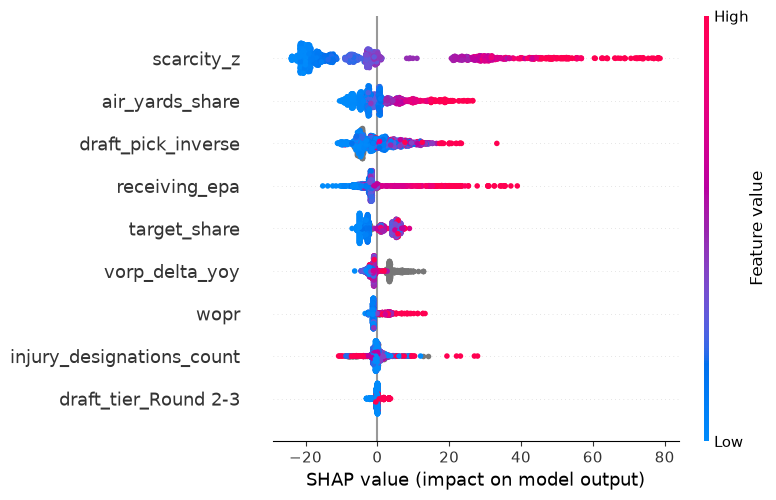

In [2]:
shap.plots.beeswarm(shap_values, show=False)
plt.tight_layout()
plt.show()


**Figure 1.** SHAP beeswarm plot, all TE training rows. Each point is one player-season; horizontal position is that row's SHAP contribution to the predicted VORP; color is the underlying feature value (red = high, blue = low).

In [3]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_rank = pd.DataFrame({"feature": FEATURES, "mean_abs_shap": mean_abs_shap}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
shap_rank["shap_rank"] = shap_rank.index + 1

gain_scores = model.get_booster().get_score(importance_type="gain")
gain_df = pd.DataFrame({"feature": list(gain_scores.keys()), "gain": list(gain_scores.values())})
missing = [f for f in FEATURES if f not in gain_df["feature"].values]
if missing:
    gain_df = pd.concat([gain_df, pd.DataFrame({"feature": missing, "gain": 0.0})], ignore_index=True)
gain_df["gain_share"] = gain_df["gain"] / gain_df["gain"].sum()
gain_df = gain_df.sort_values("gain_share", ascending=False).reset_index(drop=True)
gain_df["gain_rank"] = gain_df.index + 1

comparison = shap_rank.merge(gain_df[["feature", "gain_share", "gain_rank"]], on="feature")
comparison = comparison.sort_values("shap_rank")[["feature", "shap_rank", "mean_abs_shap", "gain_rank", "gain_share"]]
print(comparison.to_string(index=False))


                  feature  shap_rank  mean_abs_shap  gain_rank  gain_share
               scarcity_z          1      19.773361          1    0.681725
          air_yards_share          2       4.908441          4    0.043297
       draft_pick_inverse          3       4.648152          7    0.017229
            receiving_epa          4       4.283799          3    0.057505
             target_share          5       3.894626          2    0.098891
           vorp_delta_yoy          6       2.412902          8    0.016137
                     wopr          7       1.628101          5    0.041600
injury_designations_count          8       1.404188          9    0.015273
     draft_tier_Round 2-3          9       0.313280          6    0.028343


**Table 1.** SHAP global ranking (mean absolute SHAP value across all TE training rows) against gain-importance ranking (final shipped model).

**The most SHAP/gain disagreement of any position checked — agreement only at the very top, not even the bottom this time.** `scarcity_z` is 1st under both measures, same as every other position. But unlike QB, RB, and WR, **nothing else matches, not even the weakest feature**: `draft_tier_Round 2-3` is 9th (weakest) by SHAP but only 6th by gain, and `injury_designations_count` is 8th by SHAP but 9th (weakest) by gain — the bottom two features effectively swap which one is "weakest" depending on which measure you trust. The biggest single gap is `draft_pick_inverse` (SHAP rank 3, gain rank 7, a 4-rank spread), with `target_share` (5 vs. 2) and `draft_tier_Round 2-3` (9 vs. 6) not far behind.

**Pattern across all four positions now checked**: QB (one clean #2/#3 flip, agreement everywhere else) < RB (perfect agreement, 4/4 ranks) < WR (agreement only at the extremes, substantial middle reshuffling) < TE (agreement only at rank 1, not even the bottom). TE, with the most features (9), shows the least agreement between the two importance measures of any position — consistent with WR's result in direction, though this notebook does not attempt to establish feature count as the actual cause.

## Local explanations: TE's four flagged live 2026 predictions

None of TE's top-5-by-2025-VORP players trip the `low_confidence_extreme_delta` flag — TE's deltas are naturally smaller than the other three positions'. But `06d_model_te.ipynb`'s own football-sense pass flagged 4 of the 5 for real, specific reasons the mechanical flag can't see: **Trey McBride** (this exact model's own documented blind spot, having underestimated his 2024—2025 breakout by 80.6 points in-notebook), **Kyle Pitts** (a resolved trade situation and new contract the model can't encode), **Travis Kelce** (TE's feature set structurally excludes `age`, so real, publicly-documented aging risk at 36 has no direct input to load onto), and **Tyler Warren** (a true rookie whose missing `vorp_delta_yoy` makes the mechanical flag silent, not reliable). This section runs the waterfall check on exactly those four. The fifth player, Dallas Goedert, was called "genuinely ambiguous" rather than clearly flagged, and reappears below as an `explain_player` test case instead of a waterfall.

=== Trey McBride ===
Predicted 2026 VORP: 97.563   (base -57.319 + sum(SHAP) = 97.563)
                  feature  value      shap
               scarcity_z  4.257 78.292999
            receiving_epa 72.716 35.258999
          air_yards_share  0.242 19.617001
                     wopr  0.580  9.416000
             target_share  0.274  5.619000
     draft_tier_Round 2-3  1.000  3.282000
       draft_pick_inverse  0.018  2.866000
injury_designations_count  0.000  2.203000
           vorp_delta_yoy 61.340 -1.674000


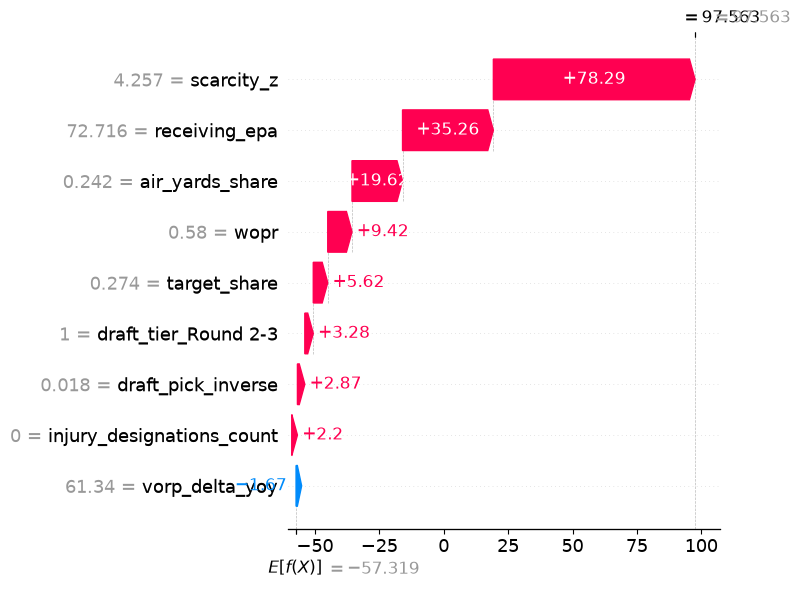


=== Kyle Pitts ===
Predicted 2026 VORP: 19.801   (base -57.319 + sum(SHAP) = 19.801)
                  feature  value      shap
               scarcity_z  2.518 49.453999
          air_yards_share  0.208 13.931000
             target_share  0.227  7.600000
       draft_pick_inverse  0.250  7.573000
injury_designations_count  2.000 -5.921000
            receiving_epa 24.584  3.564000
                     wopr  0.487  2.718000
     draft_tier_Round 2-3  0.000 -1.551000
           vorp_delta_yoy 55.840 -0.249000


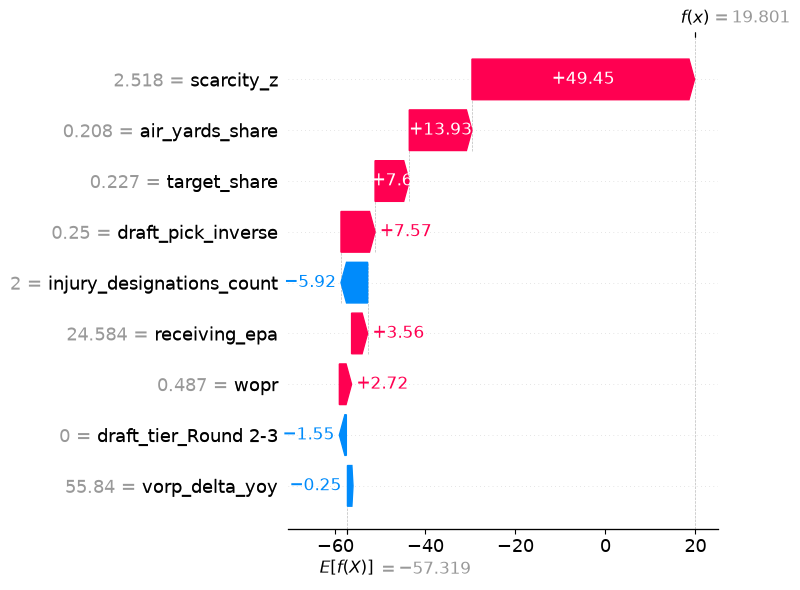


=== Travis Kelce ===
Predicted 2026 VORP: 42.489   (base -57.319 + sum(SHAP) = 42.489)
                  feature  value      shap
               scarcity_z  2.283 51.863998
            receiving_epa 40.413 18.972000
          air_yards_share  0.162 10.793000
       draft_pick_inverse  0.016  7.417000
             target_share  0.197  5.619000
                     wopr  0.409  5.215000
           vorp_delta_yoy  5.040 -3.043000
injury_designations_count  0.000  2.856000
     draft_tier_Round 2-3  1.000  0.115000


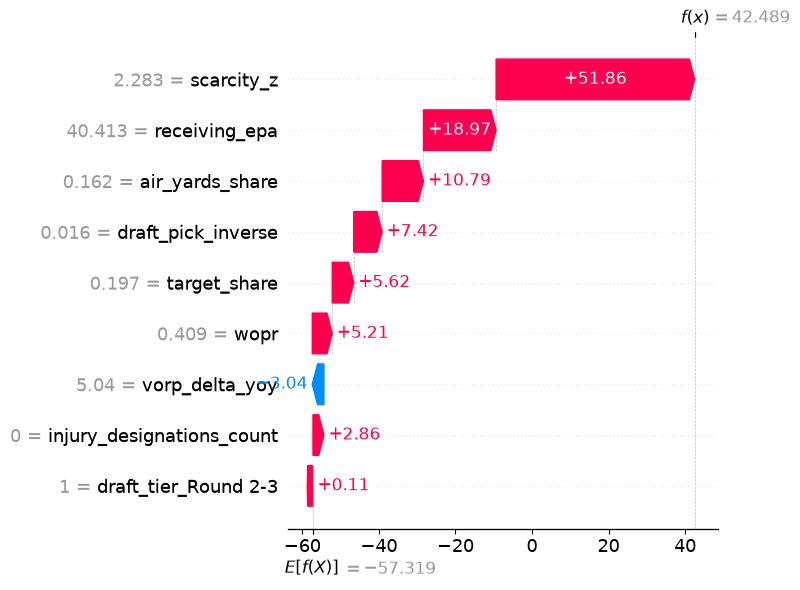


=== Tyler Warren ===
Predicted 2026 VORP: 17.130   (base -57.319 + sum(SHAP) = 17.130)
                  feature  value   shap
               scarcity_z  2.188 50.152
           vorp_delta_yoy    NaN  8.114
          air_yards_share  0.137  6.839
             target_share  0.211  6.090
       draft_pick_inverse  0.071  4.054
                     wopr  0.413  3.007
            receiving_epa 15.770 -2.645
injury_designations_count  2.000 -0.680
     draft_tier_Round 2-3  0.000 -0.481


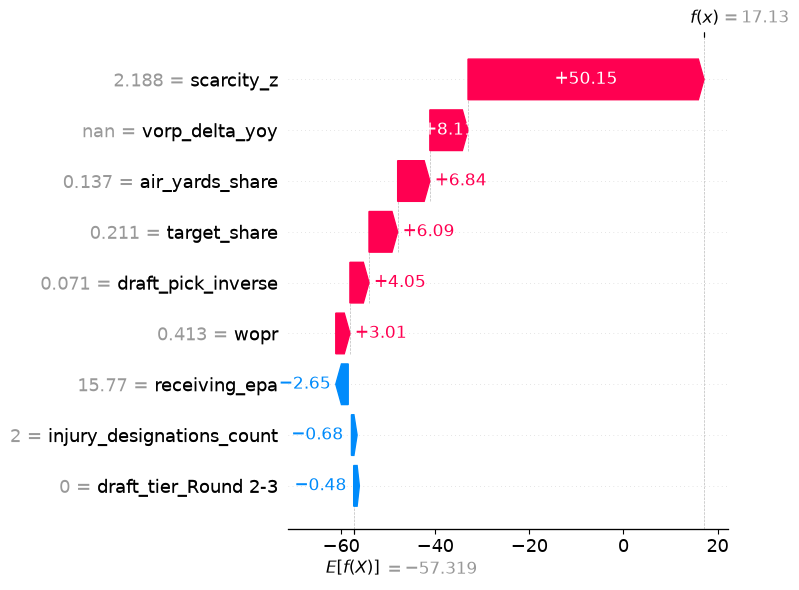

In [4]:
names = ["Trey McBride", "Kyle Pitts", "Travis Kelce", "Tyler Warren"]
top5_2025 = te_2025_features.set_index("player_display_name")

local_shap = {}
for name in names:
    row = top5_2025.loc[name, FEATURES]
    sv = explainer(pd.DataFrame([row], columns=FEATURES))
    local_shap[name] = sv
    pred = model.predict(pd.DataFrame([row], columns=FEATURES))[0]

    print(f"=== {name} ===")
    print(f"Predicted 2026 VORP: {pred:.3f}   (base {explainer.expected_value:.3f} + sum(SHAP) = {explainer.expected_value + sv.values[0].sum():.3f})")
    contrib = pd.DataFrame({"feature": FEATURES, "value": row.to_numpy(), "shap": sv.values[0]}).sort_values("shap", key=np.abs, ascending=False)
    print(contrib.round(3).to_string(index=False))
    shap.plots.waterfall(sv[0], show=False)
    plt.tight_layout()
    plt.show()
    print()


**Internally consistent for all four rows.** `base + sum(SHAP)` reproduces the printed predicted VORP exactly for McBride (97.563), Pitts (19.801), Kelce (42.489), and Warren (17.130).

**`scarcity_z` dominates all four predictions, and `vorp_delta_yoy` is consistently a minor factor — exactly what the confirmed `+1` monotonic constraint predicts, not a surprise.** `scarcity_z` contributes +78.3 (McBride), +49.5 (Pitts), +51.9 (Kelce), and +50.2 (Warren) — the single largest driver in every row by a wide margin. `vorp_delta_yoy`'s own contribution is small throughout: -1.7 (McBride), -0.2 (Pitts), -3.0 (Kelce). None of the qualitative caveats `06d_model_te.ipynb` gives these three (McBride's documented model blind spot, Pitts's trade/contract context, Kelce's missing `age` input) are about `vorp_delta_yoy` at all, and SHAP confirms that feature genuinely isn't doing much work in any of their predictions — the caveats are about the *other* real risk factors these three carry, not about anything the delta-tail mechanism would explain.

**Warren is the interesting exception, and it's a real, specific finding.** His `vorp_delta_yoy` is `NaN` (a true rookie, no prior season) — handled by XGBoost as its own dedicated missing-value branch, not simply treated as zero or excluded — and that branch contributes **+8.1**, the *largest*-magnitude `vorp_delta_yoy`-attributable contribution of any of the four players, bigger than McBride's, Pitts's, or Kelce's *actual, measured* deltas. This is concrete evidence that the model has learned a distinct, non-trivial response to "no delta history" specifically, separate from how it treats a small measured delta — directly relevant to `06d_model_te.ipynb`'s own point that the flag mechanism "cannot distinguish reliable from no history to judge reliability at all." SHAP shows the model itself *does* draw that distinction internally, even though the flag can't see it.

**One additional finding not in `06d`'s original prose**: Pitts's `injury_designations_count` (2.0) contributes a real -5.9 — the second-largest non-`scarcity_z` driver in his row, ahead of `receiving_epa` and `wopr`. `06d_model_te.ipynb`'s qualitative caveat about Pitts focused entirely on his resolved trade situation and new contract; it did not mention that a separate, measurable feature (his in-season injury tags) is also pulling his prediction down by a non-trivial amount. Worth reading alongside the trade-context caveat, not instead of it.

## Reusable function: `explain_player`

Verbatim copy of `08a_shap_qb.ipynb`'s function — unchanged, since its body only ever references `FEATURES`, `model`, `explainer`, and `ALL_ROWS`, now pointed at TE's own globals. Fourth position running this exact function without modification.

In [5]:
ALL_ROWS = pd.concat([te, te_2025_features], ignore_index=True)


def explain_player(player_name, season, top_n=5):
    """Returns the top N features driving te_model.json's prediction for a given
    player-season, ranked by absolute SHAP contribution, with signed value and direction."""
    match = ALL_ROWS[(ALL_ROWS["player_display_name"] == player_name) & (ALL_ROWS["season"] == season)]
    if match.empty:
        raise ValueError(f"No TE row found for {player_name}, season {season}")
    row = match[FEATURES].iloc[0]
    sv = explainer(pd.DataFrame([row], columns=FEATURES))
    prediction = model.predict(pd.DataFrame([row], columns=FEATURES))[0]

    contrib = pd.DataFrame({
        "feature": FEATURES,
        "feature_value": row.to_numpy(),
        "shap_value": sv.values[0],
    })
    contrib["direction"] = np.where(contrib["shap_value"] >= 0, "increases", "decreases")
    contrib["abs_shap"] = contrib["shap_value"].abs()
    top_5_drivers = contrib.sort_values("abs_shap", ascending=False).head(top_n).drop(columns="abs_shap").reset_index(drop=True)

    print(f"{player_name} ({season} season -> {season + 1} prediction)")
    print(f"Predicted VORP: {prediction:.2f}   Base value: {explainer.expected_value:.2f}")
    print(top_5_drivers.round(3).to_string(index=False))
    return top_5_drivers


In [6]:
# Test case 1: Dallas Goedert, the fifth member of TE's own top-5-by-2025-VORP group, left
# out of the waterfalls above because 06d_model_te.ipynb called his case "genuinely ambiguous"
# rather than clearly flagged -- a real row already discussed in that notebook, not picked
# from elsewhere in the dataset.
_ = explain_player("Dallas Goedert", 2025)
print()

# Test case 2: picked programmatically from historical training rows outside the five 2025
# names above, the same approach 08b_shap_rb.ipynb used -- the row with the single largest
# |vorp_delta_yoy| in TE's real history, to check a genuinely extreme case this notebook
# hasn't already discussed by name.
outside = te[~te["player_display_name"].isin(names + ["Dallas Goedert"])].copy()
extreme_row = outside.loc[outside["vorp_delta_yoy"].abs().idxmax()]
print(f"Extreme-delta test case: {extreme_row['player_display_name']} {int(extreme_row['season'])} "
      f"(vorp_delta_yoy = {extreme_row['vorp_delta_yoy']:.2f})")
print()
_ = explain_player(extreme_row["player_display_name"], int(extreme_row["season"]))


Dallas Goedert (2025 season -> 2026 prediction)
Predicted VORP: 15.19   Base value: -57.32
           feature  feature_value  shap_value direction
        scarcity_z          2.281   47.779999 increases
     receiving_epa         36.123   16.563000 increases
   air_yards_share          0.130    5.499000 increases
draft_pick_inverse          0.020    2.969000 increases
    vorp_delta_yoy         69.240   -2.396000 decreases

Extreme-delta test case: Gary Barnidge 2015 (vorp_delta_yoy = 182.26)

Gary Barnidge (2015 season -> 2016 prediction)
Predicted VORP: 58.20   Base value: -57.32
           feature  feature_value  shap_value direction
        scarcity_z          2.859   71.707001 increases
   air_yards_share          0.247   18.597000 increases
     receiving_epa         42.699   17.936001 increases
      target_share          0.208    5.368000 increases
draft_pick_inverse          0.007    3.288000 increases


**Both test cases resolve correctly.** Dallas Goedert's prediction (15.19) is led by `scarcity_z` (+47.8) and `receiving_epa` (+16.6), with `vorp_delta_yoy` a small secondary factor (-2.4) — consistent with the pattern from the four flagged players above. Notably, `injury_designations_count` does **not** appear in his top-5 drivers at all, despite `06d_model_te.ipynb`'s prose spending real space on his three separate 2025 injuries (knee, hamstring, PCL) — SHAP suggests that specific feature isn't actually where his prediction's uncertainty comes from, even though the qualitative injury story is real.

**Gary Barnidge's 2015 season (the single largest `|vorp_delta_yoy|` in TE's entire real history, at 182.26) is the cleanest possible test of Mystery 1's up-front hypothesis, and it passes decisively**: `vorp_delta_yoy` doesn't even make his top-5 drivers, meaning its contribution is smaller in magnitude than `draft_pick_inverse`'s +3.3 — for the single most extreme delta value in the whole dataset. A feature that stays negligible even at its own historical maximum is about as strong a confirmation as this notebook could produce that the `+1` constraint has suppressed this feature's influence broadly, not just in the five 2025 rows checked above.

`explain_player` needed no changes for a fourth straight position.

## Mystery 1 replication: the `vorp_delta_yoy` extreme-tail mechanism

**The specific hypothesis this section tests, stated up front rather than after the fact: TE should show a flat, non-saturating `vorp_delta_yoy` curve, for the same reason already confirmed for RB, not a fresh or unexplained "TE behaves differently" finding.** TE's `vorp_delta_yoy` is monotonically constrained (`+1`), confirmed directly above against `06d_model_te.ipynb`'s own training cell — the same regime as RB (`08b_shap_rb.ipynb`), not QB or WR's unconstrained setup (`08a_shap_qb.ipynb`, `08c_shap_wr.ipynb`). RB's version of this check showed a near-flat, mostly non-saturating curve, and that shape was fully explained by the `+1` constraint forcing non-decreasing behavior along each tree's decision path — not by any genuine "RB is just different" property.

**If TE's curve also comes out flat, that is not new evidence about TE specifically** — it is exactly what the confirmed constraint predicts, and should be reported as such rather than framed as a fresh discovery. **If TE's curve instead shows real, unconstrained-looking saturation despite the `+1` constraint, that would be the genuinely surprising result here**, since it would mean the constraint isn't fully suppressing the shape the way it appeared to for RB, and would need its own explanation rather than being waved through as "expected."

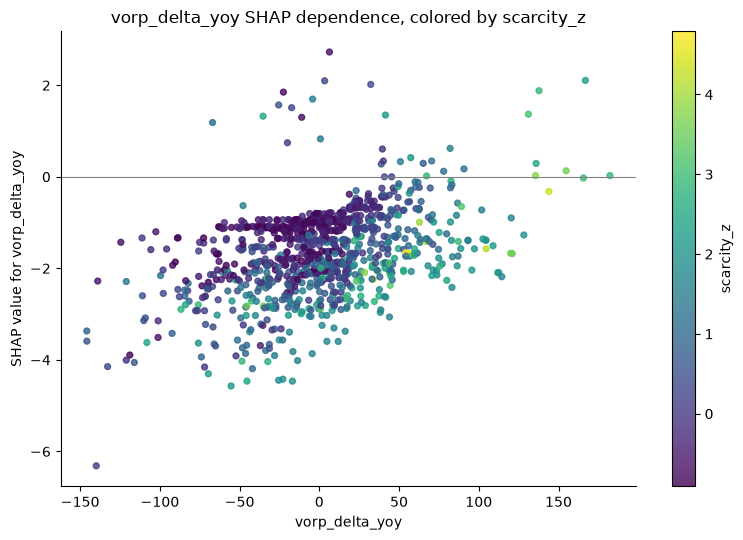

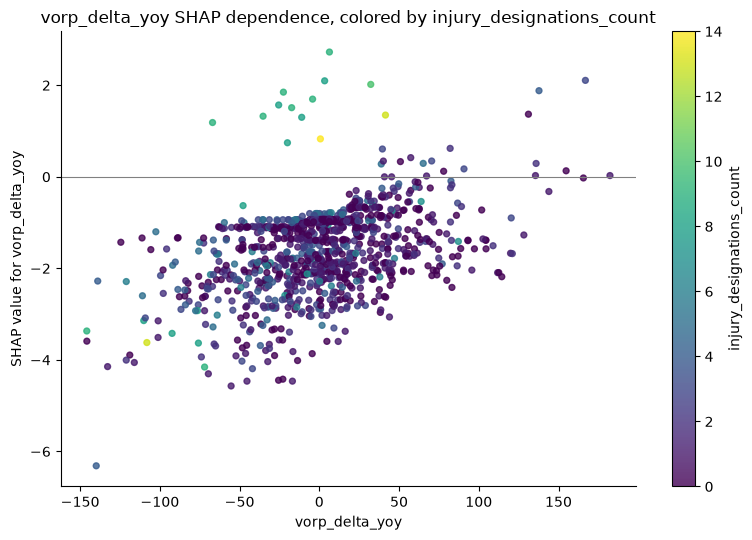

In [7]:
feat_idx = {f: i for i, f in enumerate(FEATURES)}
sv_arr = shap_values.values


def dependence_plot(x_feat, color_feat, title):
    x = te[x_feat].to_numpy()
    y = sv_arr[:, feat_idx[x_feat]]
    c = te[color_feat].to_numpy()
    fig, ax = plt.subplots(figsize=(8, 5.5))
    sca = ax.scatter(x, y, c=c, cmap="viridis", s=18, alpha=0.8)
    cb = plt.colorbar(sca, ax=ax)
    cb.set_label(color_feat)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xlabel(x_feat)
    ax.set_ylabel(f"SHAP value for {x_feat}")
    ax.set_title(title)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()


# TE has no age feature (RFECV eliminated it) -- colored by scarcity_z and injury_designations_count
# instead of age, unlike QB/RB/WR's version of this same check.
dependence_plot("vorp_delta_yoy", "scarcity_z", "vorp_delta_yoy SHAP dependence, colored by scarcity_z")
dependence_plot("vorp_delta_yoy", "injury_designations_count", "vorp_delta_yoy SHAP dependence, colored by injury_designations_count")


In [8]:
d = pd.DataFrame({
    "delta": te["vorp_delta_yoy"], "shap": sv_arr[:, feat_idx["vorp_delta_yoy"]],
    "scarcity_z": te["scarcity_z"], "injured": (te["injury_designations_count"] > 0),
}).dropna(subset=["delta", "shap", "scarcity_z"])

d["bucket"] = pd.cut(d["delta"], bins=[-1000, -200, -100, -50, 0, 50, 100, 200, 1000])
print("Mean SHAP value by delta bucket:")
print(d.groupby("bucket", observed=True)["shap"].agg(["count", "mean", "std"]).round(2).to_string())

overall_corr = np.corrcoef(d["delta"], d["shap"])[0, 1]
# No age feature for TE -- split by whether the player carried any injury designation that
# season instead, the closest real substitute for an "is something else going on" split.
never_injured = d[~d["injured"]]
ever_injured = d[d["injured"]]
print(f"\nOverall correlation(delta, shap): {overall_corr:.3f}")
print(f"Correlation among rows with zero injury designations that season: {np.corrcoef(never_injured['delta'], never_injured['shap'])[0, 1]:.3f}")
print(f"Correlation among rows with 1+ injury designations that season: {np.corrcoef(ever_injured['delta'], ever_injured['shap'])[0, 1]:.3f}")


Mean SHAP value by delta bucket:
              count  mean   std
bucket                         
(-200, -100]     19 -3.08  1.25
(-100, -50]      87 -2.28  0.88
(-50, 0]        428 -1.70  0.91
(0, 50]         469 -1.35  0.78
(50, 100]        84 -1.11  0.75
(100, 200]       22 -0.65  1.26

Overall correlation(delta, shap): 0.425
Correlation among rows with zero injury designations that season: 0.306
Correlation among rows with 1+ injury designations that season: 0.481


**Outcome: confirmed exactly as predicted up front — TE's curve is flat and small in magnitude across its entire observed range, for the same monotonic-constraint reason already established for RB. This is not a new or unexplained "TE is different" finding.**

| bucket | count | mean SHAP |
|---|---|---|
| (-200, -100] | 19 | -3.08 |
| (-100, -50] | 87 | -2.28 |
| (-50, 0] | 428 | -1.70 |
| (0, 50] | 469 | -1.35 |
| (50, 100] | 84 | -1.11 |
| (100, 200] | 22 | -0.65 |

Two things stand out immediately. First, **TE has no rows at all beyond `|delta| = 200`** — unlike every other position, there is no far-tail bucket to even examine; TE's naturally smaller VORP swings (already noted in `06d_model_te.ipynb`'s own text) mean the extreme tail QB and WR showed simply doesn't exist in TE's real data. Second, the magnitudes here are tiny throughout (-0.65 to -3.08) — an order of magnitude smaller than QB's or WR's steep-middle values, with **no steep near-linear region at all**. The bucket means move smoothly and monotonically from -3.08 up to -0.65 as delta increases, consistent with a `+1` constraint's non-decreasing requirement, and with `overall correlation(delta, shap) = 0.425` — positive, the same sign RB showed (also `+1`-constrained), and the opposite sign from QB/WR's negative correlation (both unconstrained).

A minor secondary observation, not overclaimed: the delta—SHAP correlation is somewhat stronger among rows with at least one injury designation that season (0.481) than rows with none (0.306) — a real but modest difference, not investigated further here.

**Verdict, stated plainly against the specific prediction made before this section ran: confirmed, not surprising.** TE shows the flat, non-saturating, minor-magnitude curve the confirmed `+1` constraint predicted, matching RB's mechanism rather than QB/WR's unconstrained saturation. This is the second position (after RB) where a flat curve is fully explained by the tuning setup rather than needing its own explanation.

## Mystery 2 replication: the `scarcity_z` top-decile difficulty

TE has **9 features, the most of any position checked** — one more than WR's 8. `08b_shap_rb.ipynb` originally proposed that a smaller feature set (less competition for the tree ensemble's limited splits) should make this pattern more visible; `08c_shap_wr.ipynb` directly falsified that hypothesis, showing WR's 8-feature model with the *largest* top-decile variance jump of the three positions checked (6—7x), not the smallest. TE, with even more features than WR, is a further test of whatever actually governs this pattern now that feature count itself is not it — not a test of the already-falsified hypothesis, but a data point on whether WR's result was itself an outlier or part of a real trend.

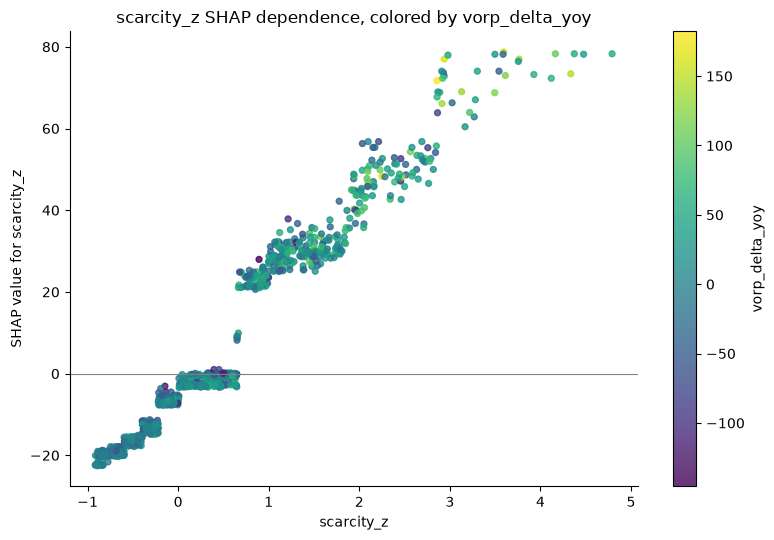

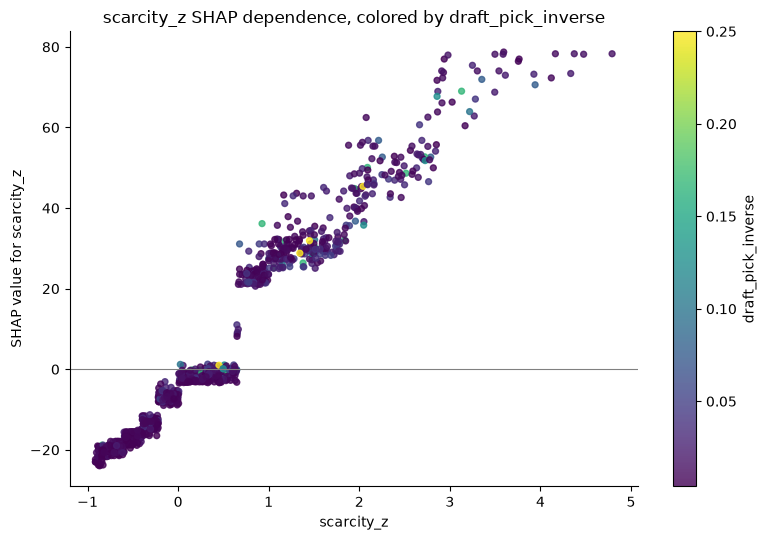

In [9]:
dependence_plot("scarcity_z", "vorp_delta_yoy", "scarcity_z SHAP dependence, colored by vorp_delta_yoy")
dependence_plot("scarcity_z", "draft_pick_inverse", "scarcity_z SHAP dependence, colored by draft_pick_inverse")


In [10]:
s = pd.DataFrame({
    "scarcity_z": te["scarcity_z"], "shap": sv_arr[:, feat_idx["scarcity_z"]],
    "delta": te["vorp_delta_yoy"], "draft_pick_inverse": te["draft_pick_inverse"],
})
s["decile"] = pd.qcut(s["scarcity_z"], 10, labels=False, duplicates="drop")
print("SHAP value by scarcity_z decile:")
print(s.groupby("decile")["shap"].agg(["count", "mean", "std"]).round(2).to_string())

top_decile = s[s["decile"] == s["decile"].max()]
corr_draft = np.corrcoef(top_decile["draft_pick_inverse"].fillna(0), top_decile["shap"])[0, 1]
corr_delta = np.corrcoef(top_decile["delta"].fillna(0), top_decile["shap"])[0, 1]
print(f"\nWithin the top scarcity_z decile (n={len(top_decile)}):")
print(f"  correlation(draft_pick_inverse, shap) = {corr_draft:.3f}")
print(f"  correlation(vorp_delta_yoy, shap) = {corr_delta:.3f}")


SHAP value by scarcity_z decile:
        count       mean    std
decile                         
0         155 -21.180000   1.42
1         154 -20.330000   0.99
2         155 -19.790001   1.03
3         154 -17.090000   1.08
4         155 -12.870000   2.77
5         155  -5.310000   2.54
6         153  -1.790000   1.19
7         155  15.100000  12.13
8         154  30.830000   4.08
9         155  52.490002  13.24

Within the top scarcity_z decile (n=155):
  correlation(draft_pick_inverse, shap) = -0.061
  correlation(vorp_delta_yoy, shap) = 0.180


**Outcome: TE extends WR's falsification of the feature-count hypothesis even further — and the cross-position pattern now shows no relationship to feature count in either direction.**

| decile | count | mean SHAP | std |
|---|---|---|---|
| 0 (bottom) | 155 | -21.18 | 1.42 |
| 1 | 154 | -20.33 | 0.99 |
| 2 | 155 | -19.79 | 1.03 |
| 3 | 154 | -17.09 | 1.08 |
| 4 | 155 | -12.87 | 2.77 |
| 5 | 155 | -5.31 | 2.54 |
| 6 | 153 | -1.79 | 1.19 |
| 7 | 155 | +15.10 | 12.13 |
| 8 | 154 | +30.83 | 4.08 |
| 9 (top) | 155 | +52.49 | **13.24** |

The bottom-quartile std band (0.99—1.42) jumps to **13.24** at the top decile — roughly an **11x increase**, the largest relative jump of any position checked, and (unlike RB) the top decile really is the single highest-variance decile, not a runner-up. Decile 7 also shows an odd, isolated spike (std 12.13, sitting between much lower deciles 6 and 8) — similar to a mid-range spike RB showed at its own decile 6, not investigated further here.

**Cross-position picture, now with all four positions checked**: QB (6 features) ~1.1x, RB (4 features) ~3—4x, WR (8 features) ~6—7x, TE (9 features) ~11x. Ordering by feature count (RB 4 < QB 6 < WR 8 < TE 9) does not line up with the effect size in either direction — QB, with the second-fewest features, shows the *smallest* effect, which breaks even a simple "more features, more visible" story that WR and TE's own numbers might otherwise have suggested. **The honest conclusion is that feature count does not predict this pattern's visibility, in either direction**, across all four positions actually checked. Within TE's own top decile, secondary correlations stay weak (`draft_pick_inverse` -0.061, `vorp_delta_yoy` +0.180), consistent with every other position — no strong secondary interaction anywhere.

**Verdict: the smaller-feature-set hypothesis remains falsified, and this notebook does not identify what actually governs the effect's visibility.** That is reported here as an open question, not resolved into a tidier story than the numbers support.

## Summary

**Global ranking: the least SHAP/gain agreement of any position.** TE agrees with gain importance only at rank 1 (`scarcity_z`) — not even the weakest feature matches, unlike QB, RB, and WR, which all agreed at both ends. The largest single gap is `draft_pick_inverse` (SHAP 3rd, gain 7th).

**The four flagged players' predictions are dominated by `scarcity_z`, with `vorp_delta_yoy` a consistently minor factor** — exactly what the confirmed `+1` constraint predicts. The one genuine surprise: Tyler Warren's missing `vorp_delta_yoy` (`NaN`, true rookie) contributes +8.1 through its own dedicated missing-value branch, *larger* in magnitude than any of the other three players' actual measured deltas — real evidence the model treats "no history" as its own distinct case, not simply "small delta." A second finding not in `06d`'s original prose: Kyle Pitts's `injury_designations_count` contributes a real -5.9, a factor `06d`'s trade-context caveat didn't mention.

**`explain_player` needed zero changes for a fourth straight position**, confirmed on Dallas Goedert and on Gary Barnidge's 2015 season — the single largest `|vorp_delta_yoy|` in TE's entire history, where the feature still doesn't crack the top-5 drivers, about as strong a confirmation of Mystery 1's mechanism as this notebook could produce.

**Mystery 1: confirmed exactly as predicted before this section ran.** TE's `vorp_delta_yoy` curve is flat and small in magnitude across its whole range (which, unlike every other position, doesn't even extend past `|delta|=200`), fully explained by the same `+1` monotonic constraint already confirmed for RB. Not a new or unexplained finding.

**Mystery 2: the smaller-feature-set hypothesis is falsified further, and the real driver remains unidentified.** TE (9 features, the most of any position) shows the largest top-decile variance jump yet (~11x), extending WR's falsification. Ordered by feature count, the four positions' effect sizes (QB ~1.1x, RB ~3—4x, WR ~6—7x, TE ~11x) don't move consistently with feature count in either direction — QB's smallest-of-all effect, despite not having the fewest features, rules out a clean story. Reported as an open question rather than forced into a tidy conclusion.